In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent
print("Project:", PROJECT_DIR)

Project: /Users/trantuananh/Programming folder/Deep Learning Prj/plant-disease-classification


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps


In [3]:
RESULTS_DIR = PROJECT_DIR / "outputs" / "results"
CLASS_NAMES_PATH = RESULTS_DIR / "class_names.json"
PROCESSED_CSV_PATH = RESULTS_DIR / "processed_data.csv"

if not PROCESSED_CSV_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy {PROCESSED_CSV_PATH}. Hãy chạy 02_preprocessing.ipynb trước."
    )

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = json.load(f)

processed_df = pd.read_csv(PROCESSED_CSV_PATH)
required_columns = {"processed_path", "class_name", "class_id", "split"}
missing_columns = required_columns - set(processed_df.columns)
if missing_columns:
    raise ValueError(f"processed_data.csv thiếu cột: {sorted(missing_columns)}")

num_classes = len(class_names)
class_to_idx = {name: index for index, name in enumerate(class_names)}
expected_ids = processed_df["class_name"].map(class_to_idx)
if expected_ids.isna().any() or not np.array_equal(
    processed_df["class_id"].to_numpy(), expected_ids.to_numpy()
):
    raise ValueError("class_id không khớp class_names.json.")

print("Number of classes:", num_classes)
print("Processed manifest:", PROCESSED_CSV_PATH)

Number of classes: 38
Processed manifest: /Users/trantuananh/Programming folder/Deep Learning Prj/plant-disease-classification/outputs/results/processed_data.csv


In [4]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, scale=(0.90, 1.10)),
    transforms.ColorJitter(contrast=0.10),
    transforms.ToTensor(),
])
eval_transform = transforms.ToTensor()

In [5]:
BATCH_SIZE = 64


class ProcessedImageDataset(Dataset):
    def __init__(self, dataframe, project_dir, transform=None):
        self.paths = dataframe["processed_path"].astype(str).tolist()
        self.labels = dataframe["class_id"].astype(int).tolist()
        self.project_dir = Path(project_dir)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        relative_path = self.paths[index].replace("\\", "/")
        image_path = self.project_dir.joinpath(*relative_path.split("/"))
        with Image.open(image_path) as image:
            image = image.convert("RGB")
            if self.transform is not None:
                image = self.transform(image)
            else:
                image = image.copy()
        return image, self.labels[index]


def make_dataset(split_name, transform):
    subset = processed_df[processed_df["split"] == split_name].reset_index(drop=True)
    if subset.empty:
        raise ValueError(f"Split {split_name} không có dữ liệu.")
    return ProcessedImageDataset(subset, PROJECT_DIR, transform)


train_dataset = make_dataset("train", train_transform)
val_dataset = make_dataset("validation", eval_transform)
test_dataset = make_dataset("test", eval_transform)

loader_generator = torch.Generator().manual_seed(SEED)
loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": 0,
    "pin_memory": device.type == "cuda",
}
train_loader = DataLoader(
    train_dataset, shuffle=True, generator=loader_generator, **loader_options
)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

print("Split counts:", {
    "train": len(train_dataset),
    "validation": len(val_dataset),
    "test": len(test_dataset),
})
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Split counts: {'train': 37984, 'validation': 5427, 'test': 10873}
Train batches: 594
Validation batches: 85
Test batches: 170


In [6]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Image dtype:", images.dtype)
print("Min pixel:", images.min().item())
print("Max pixel:", images.max().item())

print("First labels:", labels[:10])

Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64])
Image dtype: torch.float32
Min pixel: 0.0
Max pixel: 1.0
First labels: tensor([10,  4,  9,  1, 15, 24, 15, 36, 21,  8])


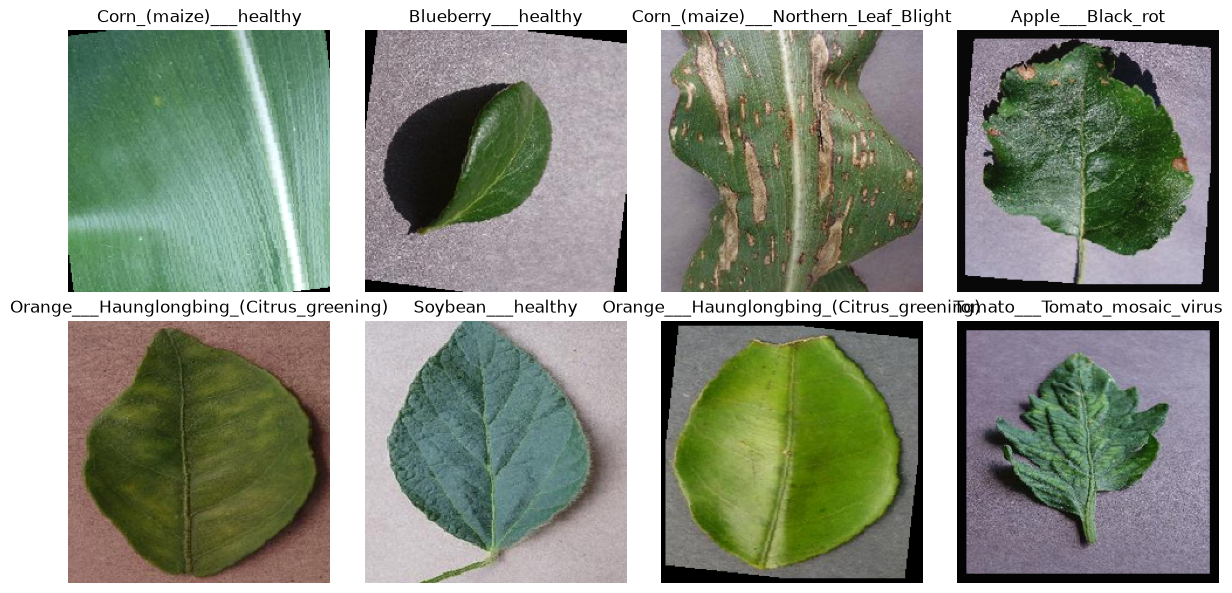

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0).numpy()
    label = labels[i].item()

    ax.imshow(image)
    ax.set_title(class_names[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
import torch
import torch.nn as nn


class SimpleCNN(nn.Module):
    def __init__(self, num_classes=38):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 4
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)

        return x

In [9]:
model = SimpleCNN(
    num_classes=num_classes
).to(device)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=38, bias=True

In [10]:
total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 426,214
Trainable parameters: 426,214


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [12]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Reset gradient
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [13]:
def evaluate(
    model,
    dataloader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item()
                * images.size(0)
            )

            _, predictions = torch.max(
                outputs,
                1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [14]:
EPOCHS = 10

In [15]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    val_loss, val_acc = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device,
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/10] | Train Loss: 2.5848 | Train Acc: 0.2913 | Val Loss: 1.9815 | Val Acc: 0.4212
Epoch [2/10] | Train Loss: 1.5343 | Train Acc: 0.5395 | Val Loss: 1.1178 | Val Acc: 0.6438
Epoch [3/10] | Train Loss: 0.9388 | Train Acc: 0.7077 | Val Loss: 0.7515 | Val Acc: 0.7656
Epoch [4/10] | Train Loss: 0.6781 | Train Acc: 0.7873 | Val Loss: 0.6214 | Val Acc: 0.8056
Epoch [5/10] | Train Loss: 0.5538 | Train Acc: 0.8256 | Val Loss: 0.5592 | Val Acc: 0.8233
Epoch [6/10] | Train Loss: 0.4493 | Train Acc: 0.8571 | Val Loss: 0.4694 | Val Acc: 0.8519
Epoch [7/10] | Train Loss: 0.3878 | Train Acc: 0.8742 | Val Loss: 0.3659 | Val Acc: 0.8852
Epoch [8/10] | Train Loss: 0.3311 | Train Acc: 0.8938 | Val Loss: 0.5002 | Val Acc: 0.8426
Epoch [9/10] | Train Loss: 0.2922 | Train Acc: 0.9064 | Val Loss: 0.3642 | Val Acc: 0.8869
Epoch [10/10] | Train Loss: 0.2577 | Train Acc: 0.9154 | Val Loss: 0.2745 | Val Acc: 0.9162


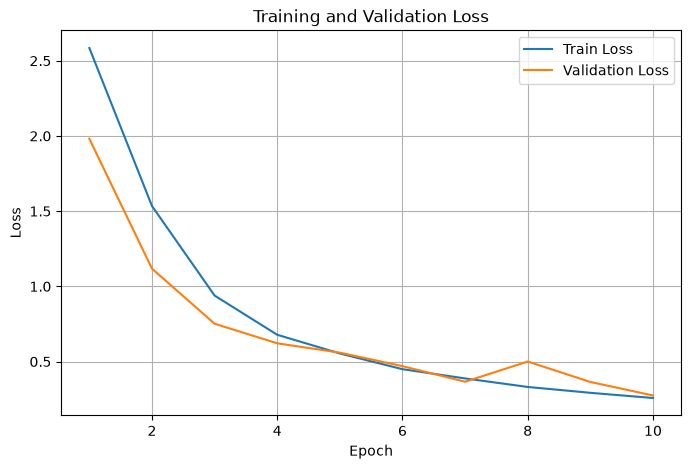

In [16]:
epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

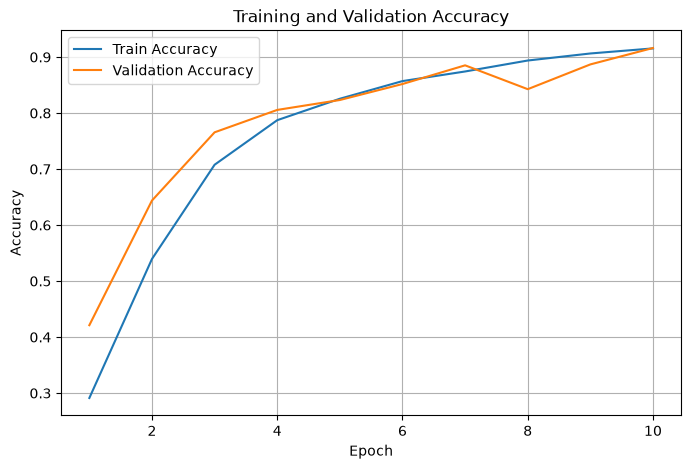

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

In [18]:
test_loss, test_accuracy = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device,
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.2663
Test Accuracy: 0.9176


In [19]:
all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

print("Number of test samples:", len(all_labels))

Number of test samples: 10873


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.9176
Precision: 0.9231
Recall   : 0.9176
F1-score : 0.9152


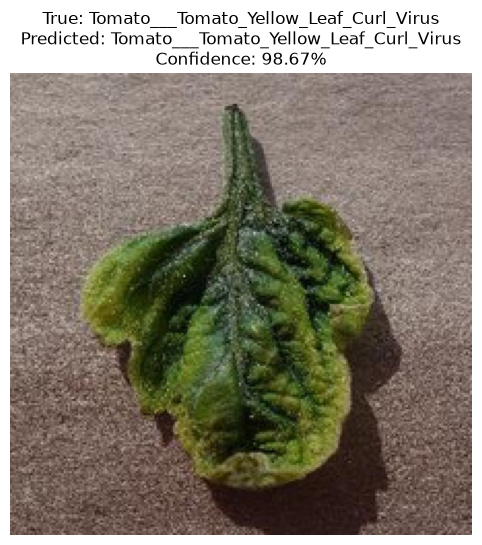

True class      : Tomato___Tomato_Yellow_Leaf_Curl_Virus
Predicted class : Tomato___Tomato_Yellow_Leaf_Curl_Virus
Confidence      : 98.67%


In [21]:
import random
import matplotlib.pyplot as plt

# Lấy dataset của test_loader
test_dataset = test_loader.dataset

# Chọn ngẫu nhiên một ảnh
random_index = random.randint(0, len(test_dataset) - 1)

image, true_label = test_dataset[random_index]

# Thêm batch dimension: [3, H, W] -> [1, 3, H, W]
input_image = image.unsqueeze(0).to(device)

# Predict
model.eval()

with torch.no_grad():
    output = model(input_image)

    probabilities = torch.softmax(output, dim=1)

    predicted_label = probabilities.argmax(dim=1).item()
    confidence = probabilities[0, predicted_label].item()

# Lấy tên class
true_class = class_names[true_label]
predicted_class = class_names[predicted_label]

# Hiển thị ảnh
display_image = image.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(6, 6))
plt.imshow(display_image)
plt.axis("off")

plt.title(
    f"True: {true_class}\n"
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2%}"
)

plt.show()

print("True class      :", true_class)
print("Predicted class :", predicted_class)
print(f"Confidence      : {confidence:.2%}")

In [22]:
top_probs, top_indices = torch.topk(
    probabilities[0],
    k=5
)

print("Top 5 predictions:")

for rank, (prob, idx) in enumerate(
    zip(top_probs, top_indices),
    start=1
):
    print(
        f"{rank}. {class_names[idx.item()]} "
        f"- {prob.item():.2%}"
    )

Top 5 predictions:
1. Tomato___Tomato_Yellow_Leaf_Curl_Virus - 98.67%
2. Tomato___Spider_mites Two-spotted_spider_mite - 1.32%
3. Tomato___Late_blight - 0.02%
4. Pepper,_bell___Bacterial_spot - 0.00%
5. Tomato___Target_Spot - 0.00%
